# Testes com OSMnx

- documentação: https://osmnx.readthedocs.io/en/stable/getting-started.html

- "is built on top of NetworkX and GeoPandas, and interacts with OpenStreetMap APIs"



In [1]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

print(f'OSMnx versão: {ox.__version__}')
print(f'NetworkX versão: {nx.__version__}')

OSMnx versão: 2.1.0
NetworkX versão: 3.6.1


In [2]:
# rede de ruas (caminhável) da região da Vila Mariana, São Paulo
# apenas ruas onde pedestres podem caminhar

G_vm = ox.graph_from_place("Vila Mariana, São Paulo, Brazil", network_type="walk")

print(f'Nós: {G_vm.number_of_nodes()}')
print(f'Arestas: {G_vm.number_of_edges()}')

Nós: 4386
Arestas: 12076


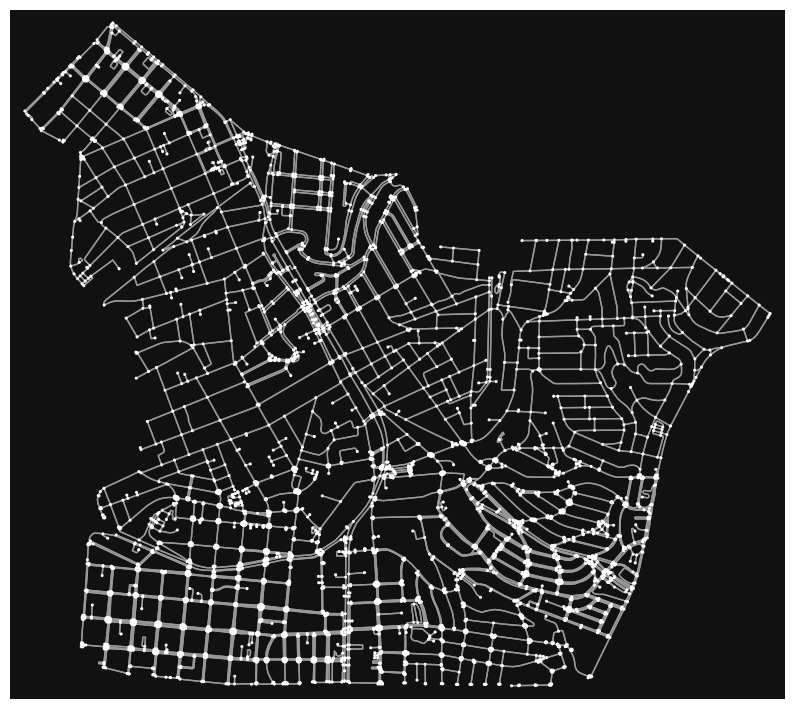

In [3]:
# Rede de ruas

fig, ax = ox.plot_graph(G_vm, figsize=(10, 10), node_size=5)

In [5]:
# conversão dos nós para um GeoDataFrame do GeoPandas

nodes_gdf = ox.graph_to_gdfs(G_vm, edges=False)

print(f'Colunas: {nodes_gdf.columns.tolist()}')
print(f'\nPrimeiras linhas:')
nodes_gdf.head()

Colunas: ['y', 'x', 'street_count', 'highway', 'railway', 'geometry']

Primeiras linhas:


,y,x,street_count,highway,railway,geometry
osmid,,,,,,
25947790,-23.578751,-46.646297,3,NaN,NaN,POINT (-46.6463 -23.57875)
26592447,-23.587221,-46.619616,3,NaN,NaN,POINT (-46.61962 -23.58722)
26592460,-23.583796,-46.617520,3,NaN,NaN,POINT (-46.61752 -23.5838)
26592462,-23.583128,-46.615565,3,traffic_signals,NaN,POINT (-46.61557 -23.58313)
40257931,-23.572995,-46.652686,4,traffic_signals,NaN,POINT (-46.65269 -23.573)


- `osmid`: ID do OpenStreetMap
- coordenadas: (x = longitude, y = latitude)

In [6]:
# Arestas

# conversão das arestas para GeoDataFrame do GeoPandas

edges_gdf = ox.graph_to_gdfs(G_vm, nodes=False)

print(f'Colunas: {edges_gdf.columns.tolist()}')
print(f'\nPrimeiras linhas:')
edges_gdf[['name', 'length', 'highway']].head(10)

Colunas: ['osmid', 'highway', 'lanes', 'name', 'oneway', 'reversed', 'length', 'geometry', 'maxspeed', 'ref', 'bridge', 'access', 'service', 'junction', 'width', 'tunnel']

Primeiras linhas:


name      length      highway
u        v          key                                                       
25947790 389062998  0    Avenida Vinte e Três de Maio   61.233195   trunk_link
         3511262197 0    Avenida Vinte e Três de Maio  100.911639        trunk
26592447 1489487202 0    Avenida Doutor Ricardo Jafet  207.928161      primary
         467820582  0               Rua Pedro Campana   92.550803  residential
         6634220142 0    Avenida Doutor Ricardo Jafet   50.118757      primary
26592460 415513348  0    Avenida Doutor Ricardo Jafet   71.473902      primary
         467830665  0             Rua Sanches Brandão   27.832329  residential
         467830655  0    Avenida Doutor Ricardo Jafet   82.010620      primary
26592462 467820476  0                Rua Rocha Galvão   67.900917  residential
         2419247883 0    Avenida Doutor Ricardo Jafet   12.459010      primary

- `length`: comprimento da aresta em metros (distância real, não em linha reta)
- `highway`: tipo de via

In [8]:
stats = ox.basic_stats(G_vm)

print(f"Comprimento total das ruas: {stats['edge_length_total']:.0f} metros")
print(f"Comprimento médio dos trechos: {stats['edge_length_avg']:.1f} metros")
print(f"Número de interseções: {stats['n']}")
print(f"Número de trechos de rua: {stats['m']}")

Comprimento total das ruas: 481387 metros
Comprimento médio dos trechos: 39.9 metros
Número de interseções: 4386
Número de trechos de rua: 12076
